<a href="https://colab.research.google.com/github/venkata18167/CSA6301---THREAT-INTELLIGENCE-AND-NETWORK-SECURITY/blob/main/24_Continuous_Security_Monitoring_with_Anomaly_Flagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Security Log Created Successfully.

Security Monitoring Logs

             Timestamp  CPU Usage (%)  Network Traffic (MB)  \
0  2026-08-03 10:00:00             93                    83   
1  2026-08-03 10:01:00             81                   641   
2  2026-08-03 10:02:00             46                   523   
3  2026-08-03 10:03:00             55                   719   
4  2026-08-03 10:04:00             24                   583   
5  2026-08-03 10:05:00             61                   127   
6  2026-08-03 10:06:00             66                    95   
7  2026-08-03 10:07:00             37                   667   
8  2026-08-03 10:08:00             68                   481   
9  2026-08-03 10:09:00             53                   517   

   Failed Login Attempts  
0                      6  
1                      0  
2                      7  
3                      2  
4                      7  
5                      3  
6                      6  
7                    

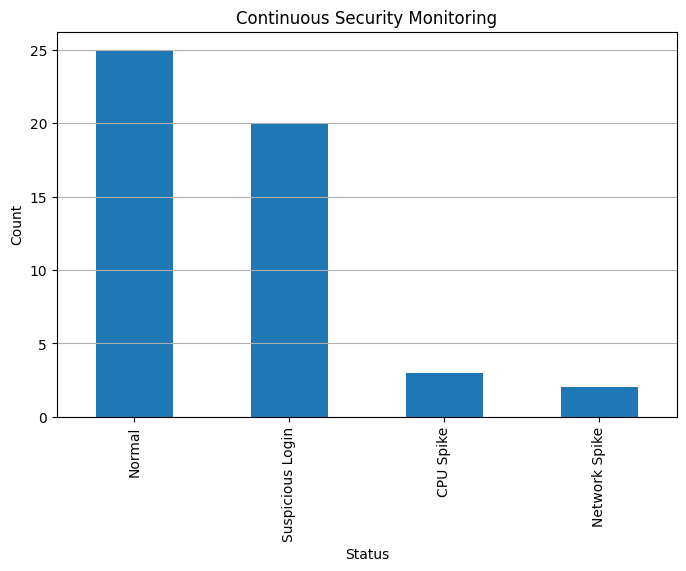


========== FINAL REPORT ==========
Total Events : 50
Normal Events : 25
CPU Spikes : 3
Network Spikes : 2
Suspicious Logins : 20

Monitoring Completed Successfully.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

random.seed(10)

start_time = datetime(2026, 8, 3, 10, 0, 0)

logs = []

for i in range(50):

    timestamp = start_time + timedelta(minutes=i)

    cpu = random.randint(20, 95)
    network = random.randint(50, 900)
    login_failures = random.randint(0, 8)

    logs.append([
        timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        cpu,
        network,
        login_failures
    ])

df = pd.DataFrame(
    logs,
    columns=[
        "Timestamp",
        "CPU Usage (%)",
        "Network Traffic (MB)",
        "Failed Login Attempts"
    ]
)

df.to_csv("Security_Monitoring_Log.csv", index=False)

print("Sample Security Log Created Successfully.\n")

data = pd.read_csv("Security_Monitoring_Log.csv")

print("Security Monitoring Logs\n")
print(data.head(10))

def detect(row):

    if row["CPU Usage (%)"] > 85:
        return "CPU Spike"

    elif row["Network Traffic (MB)"] > 750:
        return "Network Spike"

    elif row["Failed Login Attempts"] >= 5:
        return "Suspicious Login"

    else:
        return "Normal"

data["Status"] = data.apply(detect, axis=1)

print("\n===============================")
print(" SECURITY ALERTS ")
print("===============================")

alerts = data[data["Status"] != "Normal"]

for index, row in alerts.iterrows():

    print("-----------------------------------")
    print("Time :", row["Timestamp"])
    print("Alert:", row["Status"])
    print("CPU :", row["CPU Usage (%)"], "%")
    print("Network :", row["Network Traffic (MB)"], "MB")
    print("Failed Logins :", row["Failed Login Attempts"])


alerts.to_csv("Anomaly_Report.csv", index=False)

print("\nAnomaly report saved as Anomaly_Report.csv")


summary = data["Status"].value_counts()

print("\nSummary\n")
print(summary)

plt.figure(figsize=(8,5))

summary.plot(kind="bar")

plt.title("Continuous Security Monitoring")
plt.xlabel("Status")
plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

print("\n========== FINAL REPORT ==========")

print("Total Events :", len(data))
print("Normal Events :", len(data[data["Status"]=="Normal"]))
print("CPU Spikes :", len(data[data["Status"]=="CPU Spike"]))
print("Network Spikes :", len(data[data["Status"]=="Network Spike"]))
print("Suspicious Logins :", len(data[data["Status"]=="Suspicious Login"]))

print("\nMonitoring Completed Successfully.")